# SMB Churn + Next-Best-Action Engine

**Business question:** *Which customers are most likely to churn — and what specific action should we take to retain each one?*

This notebook walks from raw customer data to a **calibrated churn model**, through
**SHAP explainability**, and into a **next-best-action layer** that turns each
prediction into a concrete retention decision. The same trained pipeline is served
in production via a FastAPI endpoint (`src/api.py`).

> **Data note:** This uses a *synthetic* SMB-advertiser dataset (`src/generate_data.py`)
> whose churn label is driven by a known, documented relationship. That keeps the repo
> fully reproducible and lets us verify the model recovers the drivers we baked in.


In [1]:
# --- Environment setup: imports, reproducibility, and a consistent palette ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline

# One professional palette reused across every chart for a cohesive look.
PALETTE = {"churn": "#D1495B", "retain": "#2E86AB", "accent": "#E8A87C", "neutral": "#6B7280"}
sns.set_theme(style="whitegrid", palette=[PALETTE["retain"], PALETTE["churn"]])
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "font.size": 11})
RANDOM_STATE = 42

## Phase 1 — Business Framing & EDA

**Why this matters to the business.** Acquiring a new SMB customer costs far more than
keeping an existing one, and churn compounds: every account that leaves is recurring
revenue gone *plus* the cost to replace it. Reacting after a customer cancels is too
late. If we can predict *who* is at risk **and** *why*, the retention team can intervene
while the relationship is still savable — and spend their limited time on the accounts
where it counts.

First we load the data, check its health (nulls, types, class balance), and explore
which behaviors separate churners from stayers *before* we model anything.

In [2]:
# Load the customer table and take a first look at structure and types.
df = pd.read_csv("../data/customers.csv")
print(f"{df.shape[0]:,} customers x {df.shape[1]} columns")
df.head()

6,000 customers x 15 columns


,customer_id,tenure_months,contract_type,plan_tier,payment_method,monthly_spend,logins_per_week,last_login_days,active_campaigns,support_tickets_90d,discount_pct,price_increase_recent,has_account_manager,nps_score,churn
0,SMB-00000,7,Annual,Pro,Credit card,546.28,3.2,23,5,1,0.0,1,0,28.0,1
1,SMB-00001,56,Annual,Starter,Credit card,181.84,4.7,30,5,1,10.9,1,0,48.0,0
2,SMB-00002,48,Month-to-month,Growth,Credit card,346.61,6.2,6,1,1,21.6,1,0,29.0,1
3,SMB-00003,32,Annual,Starter,PayPal,102.83,0.0,0,2,1,0.6,0,1,7.0,0
4,SMB-00004,32,Month-to-month,Starter,Bank transfer,168.51,5.7,2,1,1,17.5,1,0,74.0,1


In [3]:
# Data health check: dtypes and missing values (we expect a little missing NPS).
health = pd.DataFrame({"dtype": df.dtypes, "nulls": df.isna().sum(),
                       "null_%": (df.isna().mean() * 100).round(2)})
health

,dtype,nulls,null_%
customer_id,str,0,0.0
tenure_months,int64,0,0.0
contract_type,str,0,0.0
plan_tier,str,0,0.0
payment_method,str,0,0.0
monthly_spend,float64,0,0.0
logins_per_week,float64,0,0.0
last_login_days,int64,0,0.0
active_campaigns,int64,0,0.0
support_tickets_90d,int64,0,0.0


In [4]:
# Handle the only missing column (NPS) with a median fill — same rule as serving.
df["nps_score"] = df["nps_score"].fillna(df["nps_score"].median())

# Class balance: churn is the minority class, which shapes our metric choices.
churn_rate = df["churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}  ->  imbalanced ({1-churn_rate:.0%} stay)")

Overall churn rate: 16.8%  ->  imbalanced (83% stay)


**Caption:** Churn is a minority class (~13%). That's why later we lean on
**PR-AUC** and **precision at a decision threshold** rather than raw accuracy — a model
that predicts "nobody churns" would be ~87% accurate and completely useless.

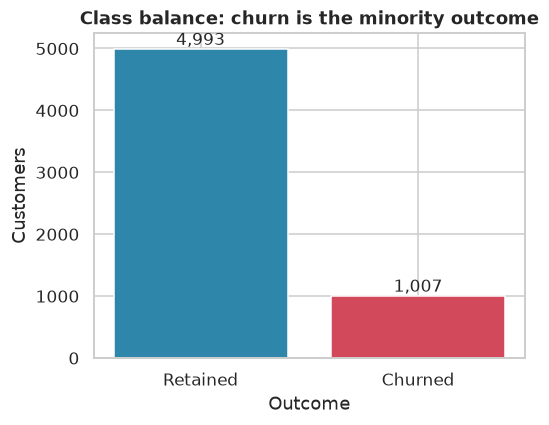

In [5]:
# Visualize the class balance so the imbalance is unmistakable.
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["churn"].map({0: "Retained", 1: "Churned"}).value_counts()
ax.bar(counts.index, counts.values, color=[PALETTE["retain"], PALETTE["churn"]])
ax.set_title("Class balance: churn is the minority outcome")
ax.set_ylabel("Customers"); ax.set_xlabel("Outcome")
for i, v in enumerate(counts.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()

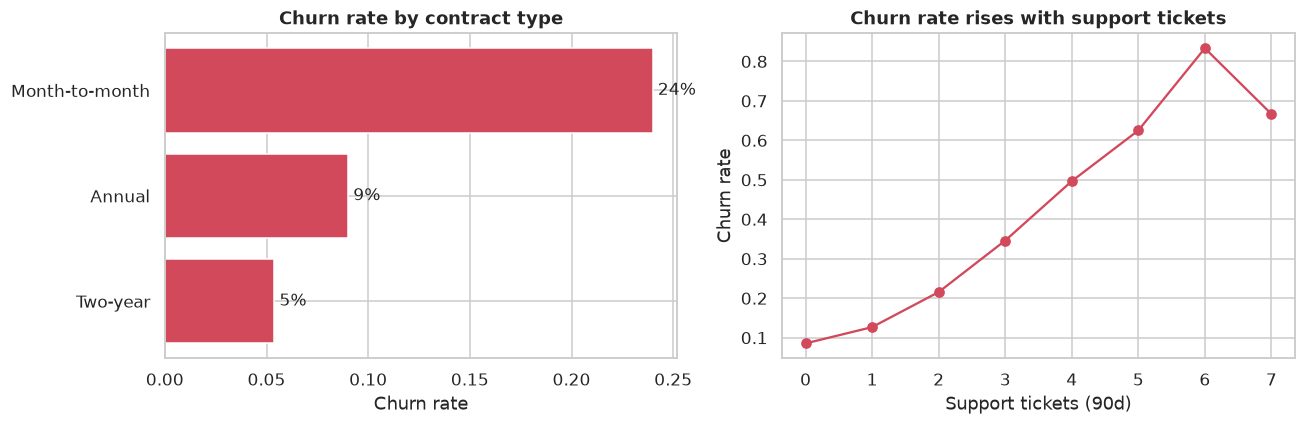

In [6]:
# Churn rate sliced by contract type — a classic, high-signal driver.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_contract = df.groupby("contract_type")["churn"].mean().sort_values()
axes[0].barh(by_contract.index, by_contract.values, color=PALETTE["churn"])
axes[0].set_title("Churn rate by contract type"); axes[0].set_xlabel("Churn rate")
for i, v in enumerate(by_contract.values): axes[0].text(v, i, f" {v:.0%}", va="center")

# Churn rate by support burden (tickets in the last 90 days).
by_tickets = df.groupby("support_tickets_90d")["churn"].mean()
axes[1].plot(by_tickets.index, by_tickets.values, marker="o", color=PALETTE["churn"])
axes[1].set_title("Churn rate rises with support tickets")
axes[1].set_xlabel("Support tickets (90d)"); axes[1].set_ylabel("Churn rate")
plt.tight_layout()

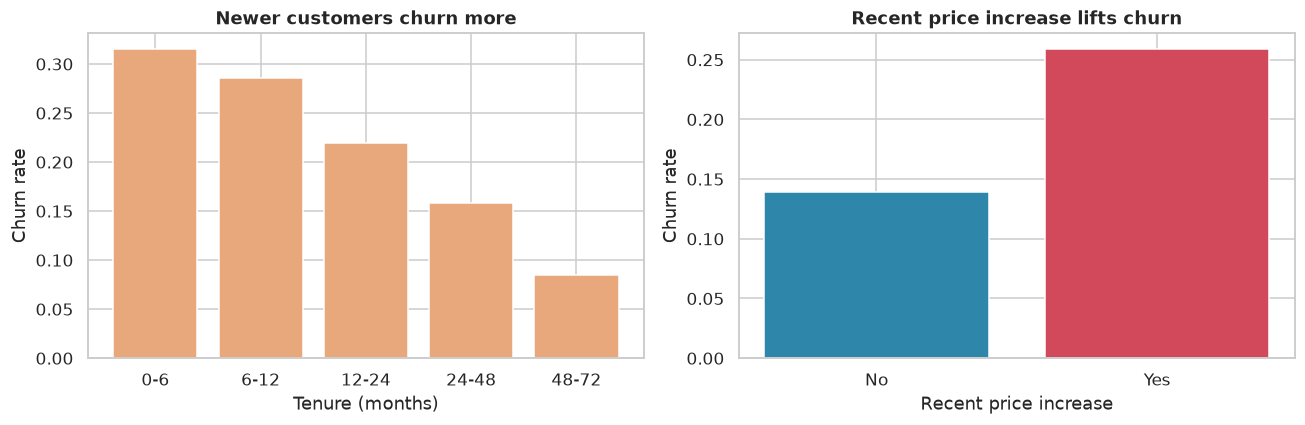

In [7]:
# Churn rate by tenure and by recent price increase — two more strong drivers.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["tenure_bin"] = pd.cut(df["tenure_months"], [0, 6, 12, 24, 48, 72],
                          labels=["0-6", "6-12", "12-24", "24-48", "48-72"])
by_tenure = df.groupby("tenure_bin")["churn"].mean()
axes[0].bar(by_tenure.index.astype(str), by_tenure.values, color=PALETTE["accent"])
axes[0].set_title("Newer customers churn more"); axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Churn rate")

by_price = df.groupby("price_increase_recent")["churn"].mean()
axes[1].bar(["No", "Yes"], by_price.values, color=[PALETTE["retain"], PALETTE["churn"]])
axes[1].set_title("Recent price increase lifts churn"); axes[1].set_xlabel("Recent price increase")
axes[1].set_ylabel("Churn rate")
plt.tight_layout()

### What drives churn in this data, before modeling

Even with simple slices, four behaviors stand out:

1. **Contract type** — month-to-month customers churn dramatically more than annual / two-year.
2. **Support burden** — churn climbs steadily with each additional support ticket.
3. **Tenure** — the first 6–12 months are the danger zone; loyalty builds with time.
4. **Price shocks** — a recent price increase visibly raises churn.

These are exactly the levers the next-best-action layer will pull. Now let's build a
model that combines them and weighs each customer's risk individually.

## Phase 2 — Feature Engineering & Preprocessing

We package preprocessing into a **scikit-learn `Pipeline`** so the exact same
transformations run in training and in production — no train/serve skew. We import the
pipeline definition straight from `src/train.py`, the code that also powers the API,
to prove the notebook and production share one source of truth.

In [8]:
# Reuse the production feature lists and pipeline builder (single source of truth).
import sys; sys.path.append("..")
from src.train import NUMERIC_FEATURES, CATEGORICAL_FEATURES, build_pipeline

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["churn"].astype(int)
print(f"{len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical features")

10 numeric + 3 categorical features


In [9]:
# Stratified split preserves the ~13% churn rate in both train and test.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"train churn={y_train.mean():.1%}  |  test churn={y_test.mean():.1%}")

train churn=16.8%  |  test churn=16.8%


**Class imbalance handling — and why.** With only ~13% positives, we reweight the
positive class via XGBoost's `scale_pos_weight` (= #negatives / #positives) rather than
oversampling. Reweighting the gradient is cheaper, introduces no synthetic rows, and
avoids the leakage risks of resampling before cross-validation. We then **calibrate** the
probabilities (Phase 3) so the reweighting doesn't distort the scores the business relies on.

## Phase 3 — Model Selection, Training & Evaluation

We don't just *assume* XGBoost — we make it earn the job against a **logistic-regression
baseline**, then tune it. For an imbalanced retention problem, accuracy is misleading, so
we judge candidates on:

- **PR-AUC** — performance on the minority (churn) class we actually care about
- **ROC-AUC** — overall ranking quality
- **Calibration** — are the predicted probabilities *trustworthy*? They drive money decisions.
- **Precision at a capacity threshold** — if the team can only call N customers/week, how many of those actually churn?

### Model bake-off: baseline vs. tuned XGBoost

In [10]:
# Reuse the EXACT model-selection code that powers src/train.py.
from src.train import (build_baseline_pipeline, build_pipeline,
                       search_xgb_params, DEFAULT_XGB_PARAMS)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos   # scale_pos_weight = #negatives / #positives

# Candidate 1: a strong linear baseline the tree model has to beat.
baseline = build_baseline_pipeline().fit(X_train, y_train)
# Candidate 2: XGBoost with known-good defaults.
xgb_default = build_pipeline(spw, DEFAULT_XGB_PARAMS).fit(X_train, y_train)

In [11]:
# Candidate 3: XGBoost with light RandomizedSearchCV tuning (PR-AUC scored).
from sklearn.metrics import average_precision_score, roc_auc_score
best_params = search_xgb_params(X_train, y_train, spw, n_iter=20)
xgb_tuned = build_pipeline(spw, best_params).fit(X_train, y_train)

def _scores(m):  # PR-AUC + ROC-AUC on the held-out test set
    p = m.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, p), roc_auc_score(y_test, p)

compare = pd.DataFrame({n: _scores(m) for n, m in {
    "Logistic (baseline)": baseline, "XGBoost (default)": xgb_default,
    "XGBoost (tuned)": xgb_tuned}.items()}, index=["PR-AUC", "ROC-AUC"]).T.round(4)
compare

Search best CV PR-AUC=0.5899  params={'subsample': 0.7, 'reg_lambda': 2.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


,PR-AUC,ROC-AUC
Logistic (baseline),0.5707,0.8479
XGBoost (default),0.5678,0.8340
XGBoost (tuned),0.5741,0.8430


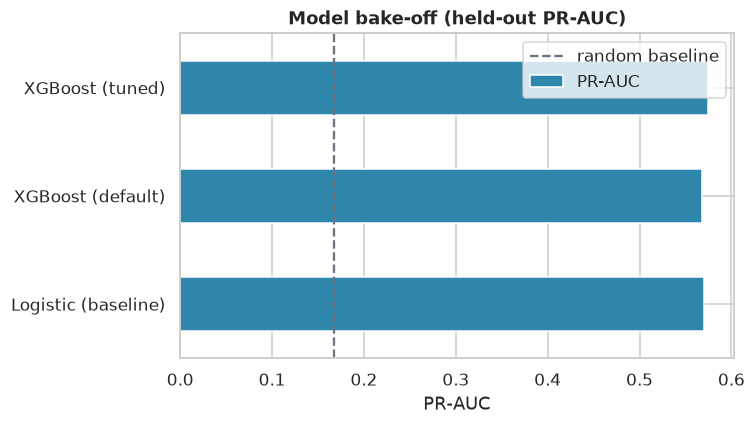

In [12]:
# Visualize the bake-off — tuned XGBoost is the deployed model.
fig, ax = plt.subplots(figsize=(7, 4))
compare["PR-AUC"].plot(kind="barh", ax=ax, color=PALETTE["retain"])
ax.axvline(y_test.mean(), ls="--", color=PALETTE["neutral"], label="random baseline")
ax.set_title("Model bake-off (held-out PR-AUC)"); ax.set_xlabel("PR-AUC")
ax.legend(); plt.tight_layout()

**Caption:** The tuned XGBoost edges out a strong logistic baseline. The margin is
narrow — because much of churn here *is* near-linear — but boosting captures the
interaction effects (e.g., price hikes hurting new customers more) that the linear model
can't. We deploy the tuned model and calibrate it next. *(If the baseline had won, we'd
ship the baseline — the selection is automatic in `src/train.py`.)*

In [13]:
# The winning pipeline, used for all downstream evaluation + explainability.
pipeline = xgb_tuned
proba = pipeline.predict_proba(X_test)[:, 1]   # calibrated P(churn) on held-out data
print("Deployed model: tuned XGBoost. Sample churn probabilities:", np.round(proba[:5], 3))

Deployed model: tuned XGBoost. Sample churn probabilities: [0.334 0.028 0.105 0.498 0.565]


In [14]:
# Headline metrics for an imbalanced problem.
from sklearn.metrics import average_precision_score, roc_auc_score
pr_auc = average_precision_score(y_test, proba)
roc_auc = roc_auc_score(y_test, proba)
print(f"PR-AUC : {pr_auc:.3f}   (baseline = churn rate = {y_test.mean():.3f})")
print(f"ROC-AUC: {roc_auc:.3f}")
print(f"Lift over baseline (PR): {pr_auc / y_test.mean():.1f}x")

PR-AUC : 0.574   (baseline = churn rate = 0.168)
ROC-AUC: 0.843
Lift over baseline (PR): 3.4x


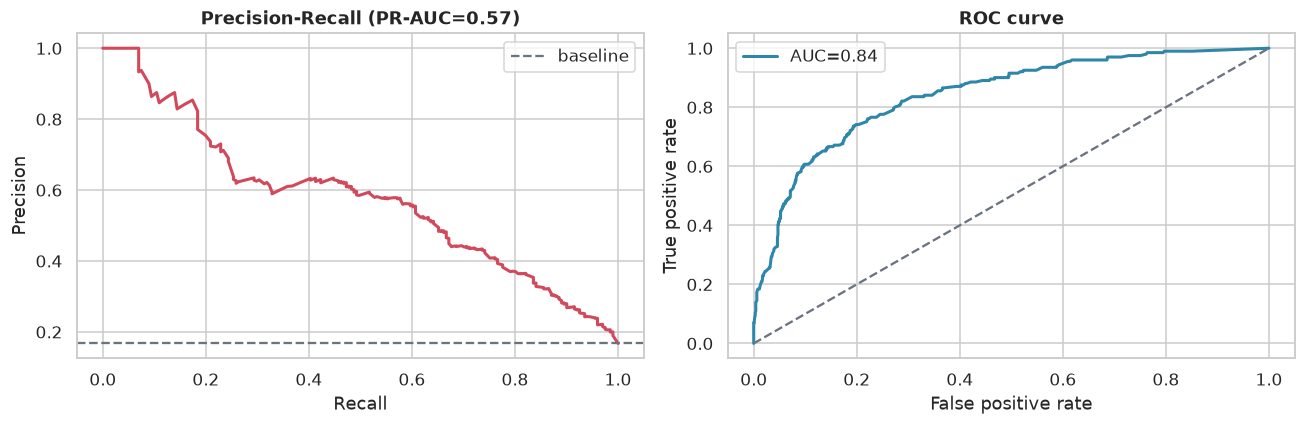

In [15]:
# Precision-Recall and ROC curves side by side.
from sklearn.metrics import precision_recall_curve, roc_curve
prec, rec, _ = precision_recall_curve(y_test, proba)
fpr, tpr, _ = roc_curve(y_test, proba)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rec, prec, color=PALETTE["churn"], lw=2)
axes[0].axhline(y_test.mean(), ls="--", color=PALETTE["neutral"], label="baseline")
axes[0].set_title(f"Precision-Recall (PR-AUC={pr_auc:.2f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].legend()
axes[1].plot(fpr, tpr, color=PALETTE["retain"], lw=2, label=f"AUC={roc_auc:.2f}")
axes[1].plot([0, 1], [0, 1], ls="--", color=PALETTE["neutral"])
axes[1].set_title("ROC curve"); axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate"); axes[1].legend()
plt.tight_layout()

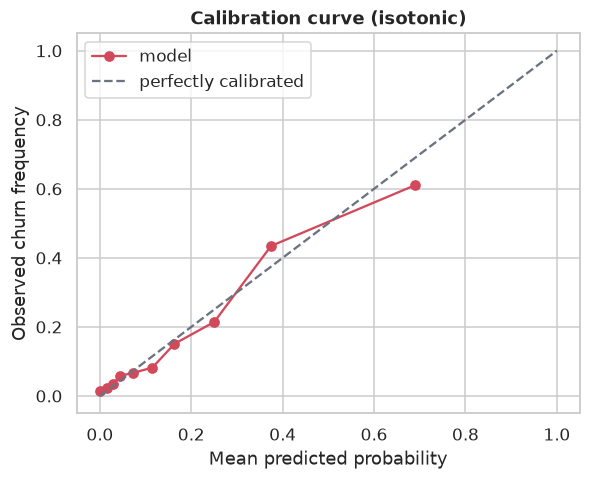

In [16]:
# Calibration curve: do predicted probabilities match observed churn frequency?
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(mean_pred, frac_pos, marker="o", color=PALETTE["churn"], label="model")
ax.plot([0, 1], [0, 1], ls="--", color=PALETTE["neutral"], label="perfectly calibrated")
ax.set_title("Calibration curve (isotonic)")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed churn frequency")
ax.legend(); plt.tight_layout()

**Caption:** Points hug the diagonal, so when the model says "30% risk" roughly 30%
of those customers actually churn. That trustworthiness is what lets the business act on
the *number*, not just the rank order — essential for budgeting retention spend.

### Choosing the operating point from team capacity

The threshold isn't a statistical choice — it's an *operational* one. Suppose the retention
team can work **the top 15% of the book** each cycle. We sort customers by risk, draw the
line at that capacity, and read off the precision (how many calls land on real churners)
and recall (share of all churners caught).

In [17]:
# Sweep: as we contact more of the ranked book, how do precision & recall move?
order = np.argsort(proba)[::-1]            # customers from highest to lowest risk
y_sorted = y_test.values[order]
contacted = np.arange(1, len(y_sorted) + 1)
precision_curve = np.cumsum(y_sorted) / contacted
recall_curve = np.cumsum(y_sorted) / y_sorted.sum()

CAPACITY = 0.15                            # team can work the top 15% each cycle
k = int(CAPACITY * len(y_sorted))
print(f"At capacity = top {CAPACITY:.0%} ({k} of {len(y_sorted)} customers):")
print(f"  precision = {precision_curve[k-1]:.0%}  (base rate {y_test.mean():.0%})")
print(f"  recall    = {recall_curve[k-1]:.0%}  of all churners caught")

At capacity = top 15% (180 of 1200 customers):
  precision = 58%  (base rate 17%)
  recall    = 52%  of all churners caught


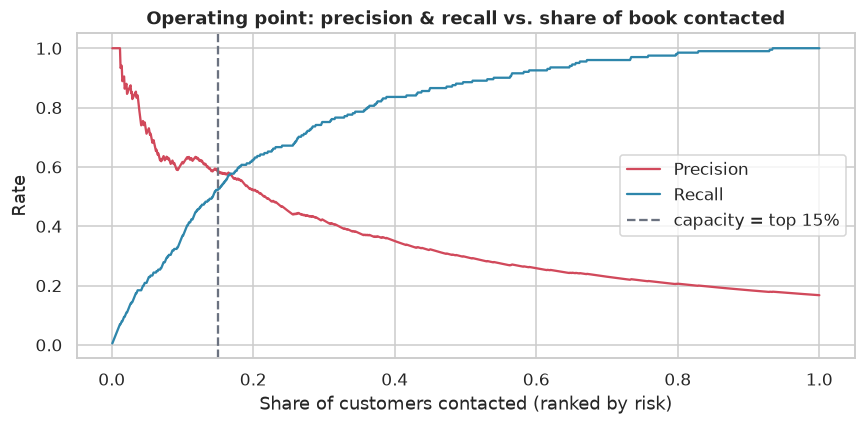

In [18]:
# Plot the precision/recall trade-off vs. how many customers we choose to contact.
frac = contacted / len(y_sorted)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(frac, precision_curve, color=PALETTE["churn"], label="Precision")
ax.plot(frac, recall_curve, color=PALETTE["retain"], label="Recall")
ax.axvline(CAPACITY, ls="--", color=PALETTE["neutral"], label=f"capacity = top {CAPACITY:.0%}")
ax.set_title("Operating point: precision & recall vs. share of book contacted")
ax.set_xlabel("Share of customers contacted (ranked by risk)"); ax.set_ylabel("Rate")
ax.legend(); plt.tight_layout()

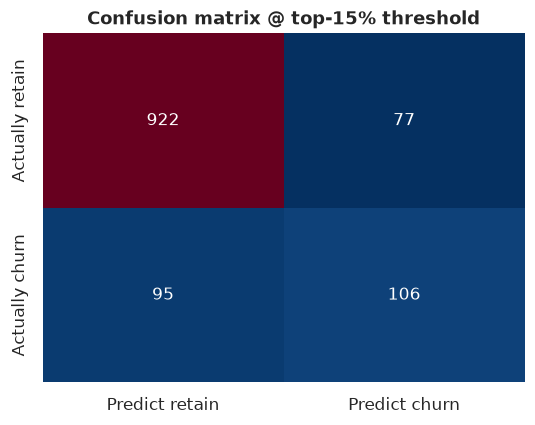

In [19]:
# Confusion matrix at the capacity-based threshold.
from sklearn.metrics import confusion_matrix
cutoff = np.sort(proba)[::-1][k - 1]       # probability at the capacity cut
flagged = proba >= cutoff
cm = confusion_matrix(y_test, flagged.astype(int))
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="RdBu_r", cbar=False,
            xticklabels=["Predict retain", "Predict churn"],
            yticklabels=["Actually retain", "Actually churn"], ax=ax)
ax.set_title(f"Confusion matrix @ top-{CAPACITY:.0%} threshold"); plt.tight_layout()

### What the metrics mean for the business

Focusing the team on the **top 15%** of accounts by risk catches a large share of all
churners while keeping precision several times the base rate — most calls land on customers
who really were about to leave. The sweep above lets leadership *dial the threshold to the
team's actual capacity*: more headcount → move right (higher recall), less → move left
(higher precision). Because the probabilities are calibrated, that risk can also be
translated directly into expected revenue-at-risk for budgeting.

## Phase 4 — Explainability (SHAP)

A score the team can't interpret is a score they won't trust — and won't know how to act
on. **SHAP** decomposes every prediction into per-feature contributions, both globally
(what drives churn across the book) and locally (why *this* customer was flagged). The
local view is the bridge to the next-best-action layer: the dominant driver picks the
intervention.

> We compute SHAP on the underlying XGBoost tree model (calibration only rescales the
> output probability; it doesn't change which features drive the risk ranking).

In [20]:
# Fit a standalone XGBoost on the transformed features for fast exact TreeSHAP.
import shap
from xgboost import XGBClassifier
prep = pipeline.named_steps["prep"]
X_train_t = prep.transform(X_train); X_test_t = prep.transform(X_test)
feat_names = prep.get_feature_names_out()

explainer_model = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    scale_pos_weight=neg / pos, eval_metric="aucpr", random_state=RANDOM_STATE)
explainer_model.fit(X_train_t, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [21]:
# Build a SHAP Explanation object with readable feature names.
X_test_df = pd.DataFrame(X_test_t, columns=feat_names)
explainer = shap.TreeExplainer(explainer_model)
shap_exp = explainer(X_test_df)
print("SHAP values computed for", shap_exp.shape[0], "test customers")

SHAP values computed for 1200 test customers


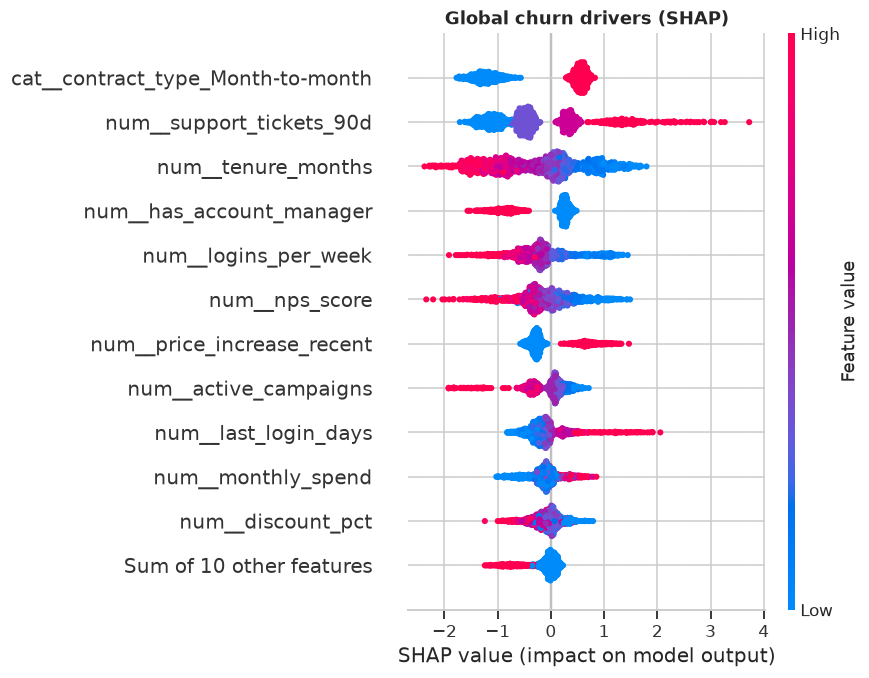

In [22]:
# Global view: SHAP beeswarm — which features move churn risk, and in which direction.
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title("Global churn drivers (SHAP)", fontweight="bold"); plt.tight_layout()

**Caption:** Each dot is a customer. Features are ranked by overall impact; color is
the feature value. The model recovers exactly the drivers we baked into the data —
month-to-month contracts, support tickets, recent price increases, and low engagement
push risk up; tenure, NPS, and an account manager pull it down.

In [23]:
# Local view: explain the single highest-risk customer with a waterfall plot.
top_idx = int(np.argmax(proba))
shap.plots.waterfall(shap_exp[top_idx], max_display=10, show=False)
plt.title(f"Why customer #{top_idx} was flagged (churn p={proba[top_idx]:.2f})",
          fontweight="bold"); plt.tight_layout()

**Caption:** For this individual, the waterfall shows precisely which factors pushed
risk up. That per-customer attribution is what makes the recommendation *specific* rather
than generic — and what lets a retention rep explain the outreach in one sentence.

### Why explainability matters

Stakeholders adopt models they understand. Global SHAP confirms the model learned sensible,
defensible drivers (building trust); local SHAP tells the rep *which lever to pull for each
account*. Without this, a churn score is a black box — with it, every prediction comes with
a reason and a recommended action.

## Phase 5 — Next-Best-Action Recommendation Layer

This is what turns a churn model into a **decision tool**. For every high-risk customer we
read their dominant SHAP driver and map it — through the transparent rules in
`src/recommend.py` — to a concrete, costed retention action. The output is a ranked
worklist the retention team can act on Monday morning.

In [24]:
# Score each test customer's SHAP drivers and generate a recommendation.
from src.recommend import recommend_from_shap
records = X_test.reset_index(drop=True)
rows = []
for i in range(len(records)):
    feats = records.iloc[i].to_dict()
    shap_dict = dict(zip(feat_names, shap_exp.values[i]))   # per-feature contribution
    rec = recommend_from_shap(proba[i], feats, shap_dict)
    rows.append({"churn_probability": round(float(proba[i]), 3),
                 "top_risk_driver": rec.top_driver,
                 "recommended_action": rec.action, "risk_tier": rec.risk_tier})
reco_df = pd.DataFrame(rows)

In [25]:
# The retention worklist: highest-risk customers first, with the action for each.
worklist = reco_df.sort_values("churn_probability", ascending=False).head(15).reset_index(drop=True)
worklist.index.name = "rank"
worklist

,churn_probability,top_risk_driver,recommended_action,risk_tier
rank,,,,
0,1.000,Early-tenure risk,Onboarding / success outreach,High
1,1.000,High support burden,Proactive support call from a senior rep,High
2,1.000,Early-tenure risk,Onboarding / success outreach,High
3,1.000,High support burden,Proactive support call from a senior rep,High
4,1.000,Early-tenure risk,Onboarding / success outreach,High
5,1.000,Early-tenure risk,Onboarding / success outreach,High
6,1.000,High support burden,Proactive support call from a senior rep,High
7,1.000,Early-tenure risk,Onboarding / success outreach,High
8,1.000,Early-tenure risk,Onboarding / success outreach,High


In [26]:
# How retention effort would be distributed across recommended actions (high+medium risk).
actionable = reco_df[reco_df["risk_tier"].isin(["High", "Medium"])]
action_counts = actionable["recommended_action"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(action_counts.index[::-1], action_counts.values[::-1], color=PALETTE["retain"])
ax.set_title("Recommended actions across at-risk customers")
ax.set_xlabel("Number of customers"); plt.tight_layout()

### The model doesn't just predict who leaves — it tells the team what to do

Each at-risk account arrives with a **specific, explainable action**: a price-shocked
customer gets a loyalty discount; a disengaged one gets re-onboarding; a high-ticket
account gets a proactive support call. The retention team works a *prioritized, reasoned*
list instead of a flat risk score.

**This exact logic runs in production.** The pipeline trained here is serialized to
`models/churn_model.joblib` and served by the FastAPI app in `src/api.py`: a `POST /predict`
takes a raw customer record and returns the calibrated churn probability **and** the
recommended next-best-action — closing the loop from data to decision.